![NYC Skyline](nyc.jpg)

Welcome to New York City, one of the most-visited cities in the world. There are many Airbnb listings in New York City to meet the high demand for temporary lodging for travelers, which can be anywhere between a few nights to many months. In this project, we will take a closer look at the New York Airbnb market by combining data from multiple file types like `.csv`, `.tsv`, and `.xlsx`.

Recall that **CSV**, **TSV**, and **Excel** files are three common formats for storing data. 
Three files containing data on 2019 Airbnb listings are available to you:

**data/airbnb_price.csv**
This is a CSV file containing data on Airbnb listing prices and locations.
- **`listing_id`**: unique identifier of listing
- **`price`**: nightly listing price in USD
- **`nbhood_full`**: name of borough and neighborhood where listing is located

**data/airbnb_room_type.xlsx**
This is an Excel file containing data on Airbnb listing descriptions and room types.
- **`listing_id`**: unique identifier of listing
- **`description`**: listing description
- **`room_type`**: Airbnb has three types of rooms: shared rooms, private rooms, and entire homes/apartments

**data/airbnb_last_review.tsv**
This is a TSV file containing data on Airbnb host names and review dates.
- **`listing_id`**: unique identifier of listing
- **`host_name`**: name of listing host
- **`last_review`**: date when the listing was last reviewed

In [178]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# upload the data into pandas dataframe
airbnb_price = pd.read_csv('data/airbnb_price.csv')
airbnb_last_review = pd.read_table('data/airbnb_last_review.tsv')
airbnb_room_type = pd.read_excel('data/airbnb_room_type.xlsx')

# join all the data on listing_id column
airbnb = pd.merge(airbnb_price, airbnb_last_review, on='listing_id')
airbnb = pd.merge(airbnb, airbnb_room_type, on='listing_id')

# get overview of the dataframe
airbnb.head()

,listing_id,price,nbhood_full,host_name,last_review,description,room_type
0,2595,225 dollars,"Manhattan, Midtown",Jennifer,May 21 2019,Skylit Midtown Castle,Entire home/apt
1,3831,89 dollars,"Brooklyn, Clinton Hill",LisaRoxanne,July 05 2019,Cozy Entire Floor of Brownstone,Entire home/apt
2,5099,200 dollars,"Manhattan, Murray Hill",Chris,June 22 2019,Large Cozy 1 BR Apartment In Midtown East,Entire home/apt
3,5178,79 dollars,"Manhattan, Hell's Kitchen",Shunichi,June 24 2019,Large Furnished Room Near B'way,private room
4,5238,150 dollars,"Manhattan, Chinatown",Ben,June 09 2019,Cute & Cozy Lower East Side 1 bdrm,Entire home/apt


In [179]:
airbnb.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 25209 entries, 0 to 25208
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   listing_id   25209 non-null  int64 
 1   price        25209 non-null  object
 2   nbhood_full  25209 non-null  object
 3   host_name    25201 non-null  object
 4   last_review  25209 non-null  object
 5   description  25199 non-null  object
 6   room_type    25209 non-null  object
dtypes: int64(1), object(6)
memory usage: 1.5+ MB


In [180]:
airbnb_dt = pd.to_datetime(airbnb['last_review']).dt.date.sort_values(ascending=False)\
            .reset_index(drop=True)
airbnb_dt

0        2019-07-09
1        2019-07-08
2        2019-07-08
3        2019-07-08
4        2019-07-08
            ...    
25204    2019-01-01
25205    2019-01-01
25206    2019-01-01
25207    2019-01-01
25208    2019-01-01
Name: last_review, Length: 25209, dtype: object

In [181]:
# The dates of the earliest and most recent reviews
most_recent_review = airbnb_dt.max()
earliest_review = airbnb_dt.min()

most_recent_review

datetime.date(2019, 7, 9)

In [182]:
earliest_review

datetime.date(2019, 1, 1)

In [183]:
airbnb['room_type'].unique()

array(['Entire home/apt', 'private room', 'Private room',
       'entire home/apt', 'PRIVATE ROOM', 'shared room',
       'ENTIRE HOME/APT', 'Shared room', 'SHARED ROOM'], dtype=object)

In [184]:
# format the string of the room_type column
airbnb['room_type'] = airbnb['room_type'].str.title()
airbnb['room_type'].unique()

array(['Entire Home/Apt', 'Private Room', 'Shared Room'], dtype=object)

In [185]:
# Find how many appearances of private rooms in room_type column
freq_private_rooms = airbnb['room_type'].value_counts()['Private Room']
freq_private_rooms

11356

<AxesSubplot: xlabel='count', ylabel='room_type'>

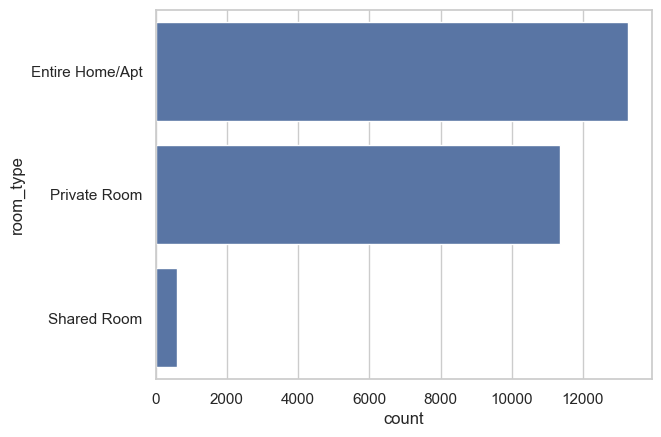

In [186]:
sns.set_style('whitegrid')
sns.countplot(airbnb['room_type'])

In [187]:
# delete 'dollars' from price column
airbnb['price'] = airbnb['price'].str.replace(' dollars', '').astype(int)
airbnb['price']

0        225
1         89
2        200
3         79
4        150
        ... 
25204    129
25205     45
25206    235
25207    100
25208     30
Name: price, Length: 25209, dtype: int64

In [188]:
avg_price = round(airbnb['price'].mean(), 2)
avg_price

141.78

In [189]:
review_dates = pd.DataFrame({
    'first_reviewed' : [earliest_review],
    'last_reviewed' : [most_recent_review],
    'nb_private_rooms' : [freq_private_rooms],
    'avg_price' : [avg_price]
})

print(review_dates)

  first_reviewed last_reviewed  nb_private_rooms  avg_price
0     2019-01-01    2019-07-09             11356     141.78
